In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
retail = pd.read_csv("data/retail_sales_dataset.csv")

In [3]:
retail.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# Описание датасета

Transaction ID: уникальный идентификатор каждой транзакции.

Date: дата совершения транзакции.

Customer ID: уникальный идентификатор каждого клиента.

Gender: пол клиента (мужской/женский).

Age: возраст клиента.

Product Category: категория приобретенного товара (например, электроника, одежда, косметика).

Quantity: количество приобретенных единиц товара.

Price per Unit: цена одной единицы товара.

Total Amount: общая денежная сумма транзакции.

# Проверка корректности значений

Посмотрим на результаты .describe, нет ли отрицательных значений. Также проверим на null и на дубликаты.

In [4]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [47]:
retail.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Year
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,2023.002000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,2023.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2023.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2023.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,2023.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,2024.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,0.044699


In [42]:
retail.describe(include='object')

,Customer ID,Gender,Product Category,Age_Group
count,1000,1000,1000,1000
unique,1000,2,3,3
top,CUST1000,Female,Clothing,Middle Age
freq,1,510,351,414


In [44]:
retail.duplicated().sum()

np.int64(0)

In [46]:
retail.isnull().mean() * 100

,0
Transaction ID,0.0
Date,0.0
Customer ID,0.0
Gender,0.0
Age,0.0
Product Category,0.0
Quantity,0.0
Price per Unit,0.0
Total Amount,0.0
Age_Group,0.0


Датасет чистый, можем анализировать.

# Распределение по полу и возрасту

In [5]:
gender_distribution = retail.groupby('Gender').agg(
    gender_count = ('Gender', 'count')
).sort_values(
    by='gender_count',
    ascending=False
).reset_index()

In [6]:
gender_distribution

,Gender,gender_count
0,Female,510
1,Male,490


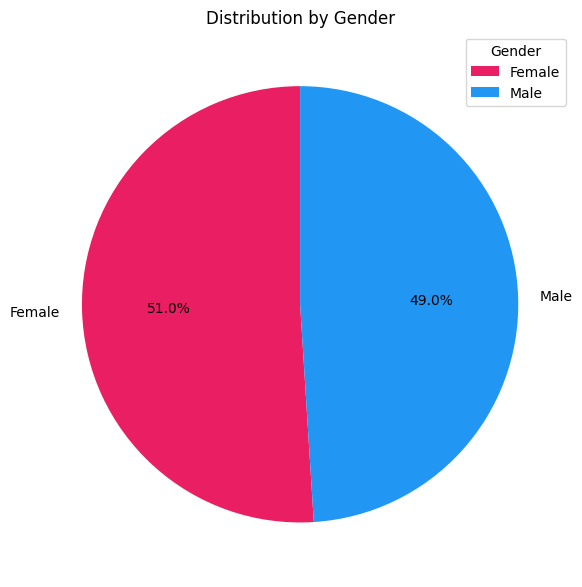

In [7]:
plt.figure(figsize=(6, 6))
colors = ['#E91E63', '#2196F3']
plt.pie(
    gender_distribution['gender_count'],
    labels=gender_distribution['Gender'],
    autopct='%1.1f%%',
    colors = colors,
    startangle=90,
)

plt.title('Distribution by Gender')
plt.legend(title='Gender', loc='upper right')
plt.tight_layout()
plt.savefig("visualization/gender_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
retail['Age_Group'] = np.where(retail['Age'] <= 30, 'Young',
                      np.where((retail['Age'] > 30) & (retail['Age'] <= 50), 'Middle Age', 'Old'))

In [9]:
age_distribution = retail.groupby('Age_Group').agg(
    age_count = ('Age_Group', 'count')).sort_values(
        by='age_count',
        ascending=False
    ).reset_index()

In [10]:
age_distribution

,Age_Group,age_count
0,Middle Age,414
1,Old,313
2,Young,273


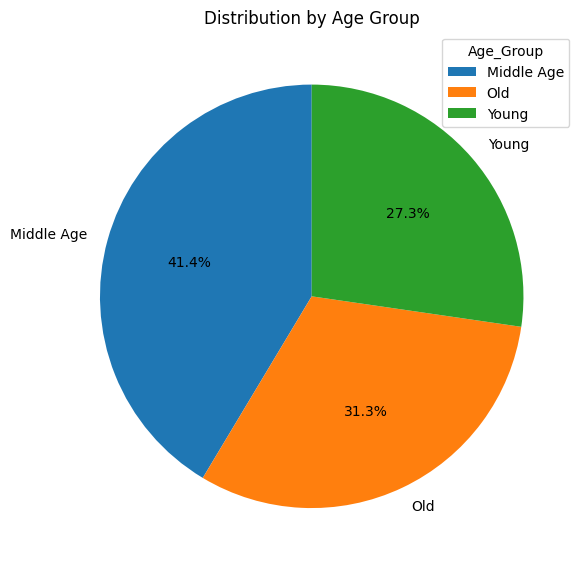

In [26]:
plt.figure(figsize=(6, 6))
plt.pie(
    age_distribution['age_count'],
    labels=age_distribution['Age_Group'],
    autopct='%1.1f%%',
    startangle=90,
)

plt.title('Distribution by Age Group')
plt.legend(title='Age_Group', loc='upper right')
plt.tight_layout()
plt.savefig("visualization/age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

По полу получили практически 50 на 50. С точки зрения возраста есть небольшой перекос в сторону людей среднего возраста (от 30 до 50 лет)

# Продажи по полу, возрасту, категории товаров

In [12]:
sales_by_category = retail.groupby('Product Category').agg(
    total_sales = ('Total Amount', 'sum')
).sort_values(
    by = 'total_sales',
    ascending=False
).reset_index()

In [13]:
sales_by_category

,Product Category,total_sales
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515


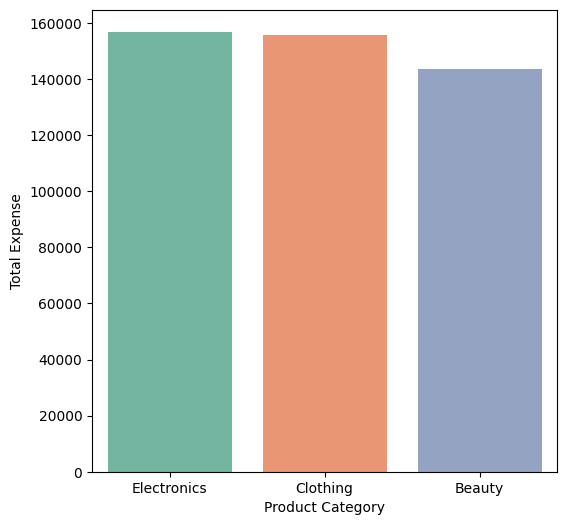

In [34]:
plt.figure(figsize=(6,6))
sns.barplot(data=sales_by_category, x='Product Category', y='total_sales', hue='Product Category', palette='Set2',)
plt.xlabel('Product Category')
plt.ylabel('Total Expense')
plt.savefig("visualization/sales_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
sales_by_gender = retail.groupby('Gender').agg(
    total_sales = ('Total Amount', 'sum')
).sort_values(
    by='total_sales',
    ascending=False
).reset_index()

In [16]:
sales_by_gender

,Gender,total_sales
0,Female,232840
1,Male,223160


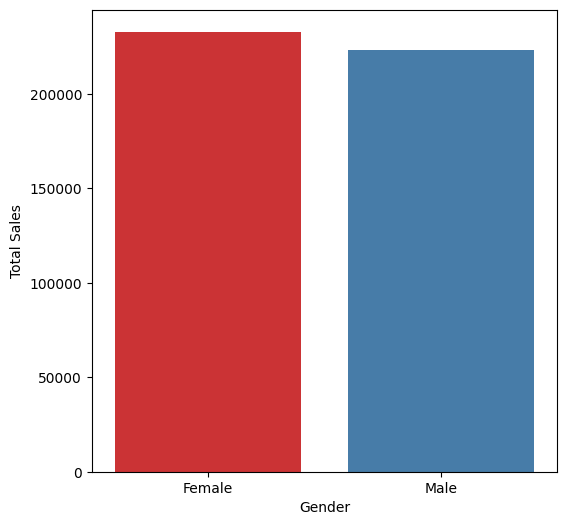

In [35]:
plt.figure(figsize=(6,6))
sns.barplot(data=sales_by_gender, x='Gender', y='total_sales', hue='Gender', palette='Set1',)
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.savefig("visualization/sales_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
sales_by_all = retail.groupby(['Gender', 'Age_Group']).agg(
    total_sales = ('Total Amount', 'sum')
).sort_values(
    by = 'total_sales',
    ascending = False
).reset_index()

In [19]:
sales_by_all

,Gender,Age_Group,total_sales
0,Female,Middle Age,95565
1,Male,Middle Age,94180
2,Female,Young,69810
3,Female,Old,67465
4,Male,Old,65845
5,Male,Young,63135


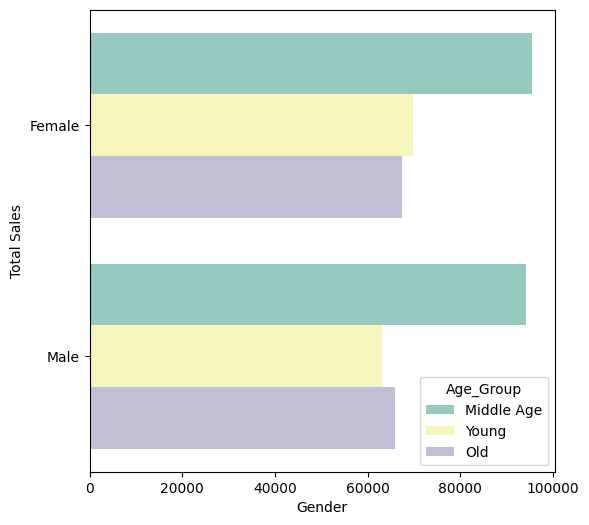

In [37]:
plt.figure(figsize=(6,6))
sns.barplot(data=sales_by_all, x='total_sales', y='Gender', hue='Age_Group', palette='Set3',)
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.savefig("visualization/sales_by_gender_and_age_group.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
sales_by_all2 = retail.groupby(['Gender', 'Age_Group', 'Product Category']).agg(
    total_sales = ('Total Amount', 'sum')
).sort_values(
    by = 'total_sales',
    ascending = False
).reset_index()

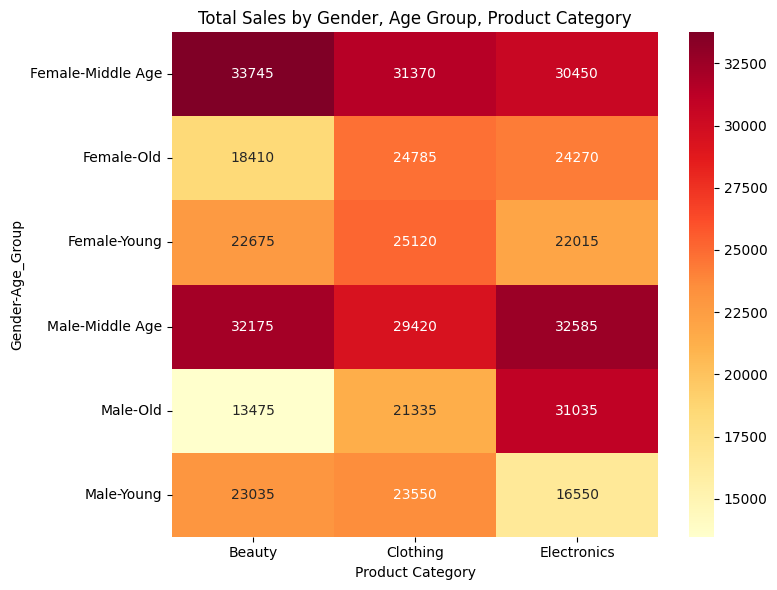

In [38]:
pivot = sales_by_all2.pivot_table(
    index=['Gender', 'Age_Group'],
    columns='Product Category',
    values='total_sales',
    fill_value=0,
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
)
plt.title('Total Sales by Gender, Age Group, Product Category')
plt.tight_layout()
plt.savefig("visualization/sales_by_all.png", dpi=150, bbox_inches="tight")
plt.show()

Видим, что большую часть прибыли приносят люди среднего возраста. Женщины среднего возраста траться в основном на категорию "Красота", мужчины же на категории "Электроника" и "Красота".

Также большую долю прибыли приносят пожилые мужчины, тратятся они на Электронику.

# Продажи в срезе времени

In [21]:
retail['Date'] = pd.to_datetime(retail['Date'])

retail['Month'] = retail['Date'].dt.month_name()
retail['Year'] = retail['Date'].dt.year

In [22]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
retail['Month'] = pd.Categorical(retail['Month'],categories=month_order,ordered=True)

In [23]:
sales_by_month = retail[retail['Year'] == 2023].groupby(['Month','Product Category']).agg(
    total_sales = ('Total Amount', 'sum')
).sort_values(
    by = 'total_sales',
    ascending = False
).reset_index()

/tmp/ipykernel_10164/3829391591.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_month = retail[retail['Year'] == 2023].groupby(['Month','Product Category']).agg(


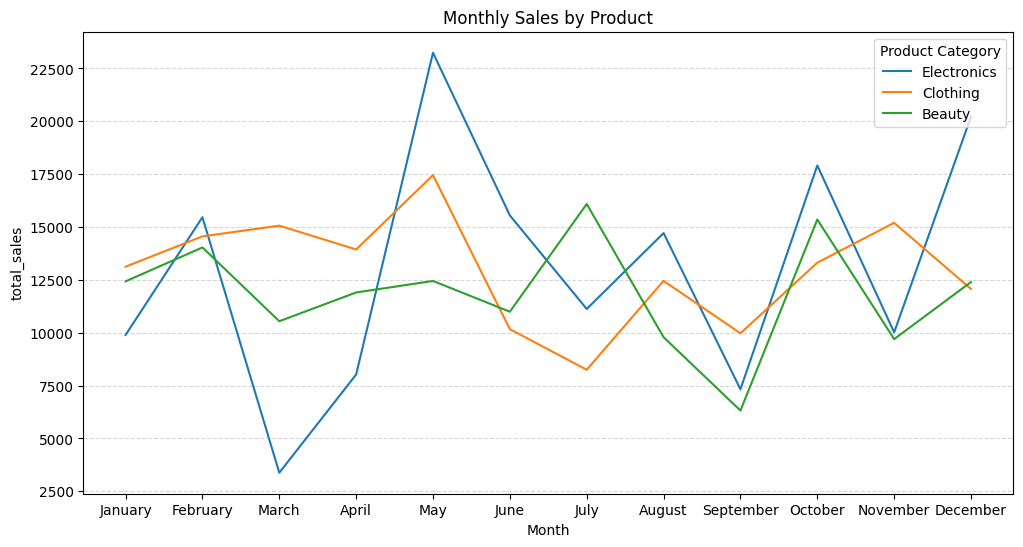

In [39]:
plt.figure(figsize=(12,6))
sns.lineplot(data=sales_by_month, y='total_sales',x='Month',hue='Product Category')
plt.title('Monthly Sales by Product')
plt.legend(title='Product Category', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("visualization/sales_by_month_lineplot.png", dpi=150, bbox_inches="tight")
plt.show()

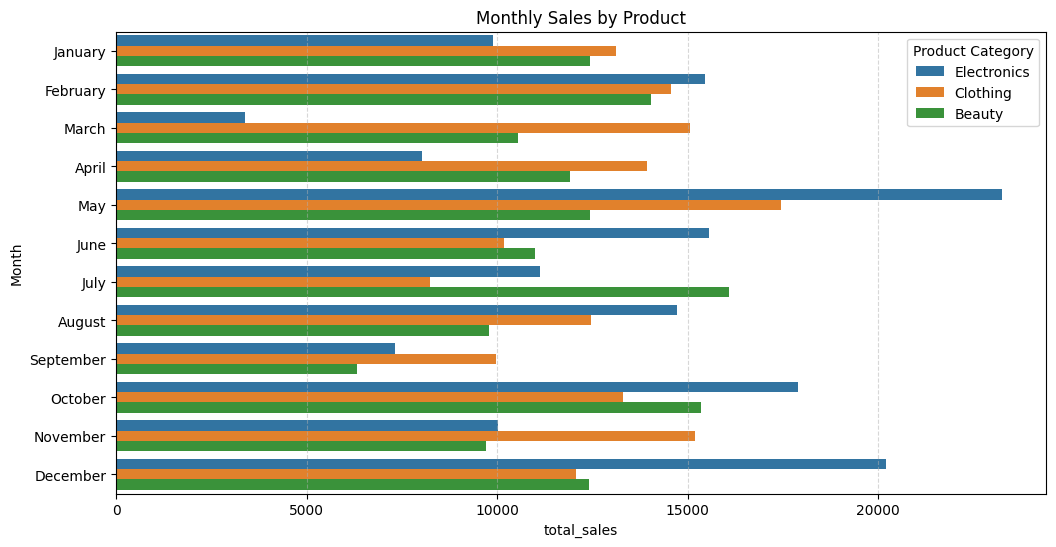

In [40]:
plt.figure(figsize=(12,6))
sns.barplot(data=sales_by_month, y='Month',x='total_sales',hue='Product Category')
plt.title('Monthly Sales by Product')
plt.legend(title='Product Category', loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.savefig("visualization/sales_by_month_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

Можем увидеть, что у каждой категории товаров есть хорошие месяцы.

Электроника: Май, Октябрь, Декабрь.
Одежда: Январь, Март, Апрель, Ноябрь.
Красота: Июль, Октябрь.